In [15]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

# PyPSA Costs

In [16]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [17]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

# Weather Data

In [18]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())

In [19]:
CF_solar = PV_data.mean(axis = 1) # average all the years

In [20]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()


In [21]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

## NG Prices

In [22]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")

In [23]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

In [24]:
gas_price_data = pd.read_excel(gas_file)

# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [25]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

In [26]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

In [27]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [28]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

# Electrcity Prices

In [29]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

In [30]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [31]:
import pandas as pd
import numpy as np

def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    """
    Inputs:
        Elspotprices : pd.DataFrame (containing 'SpotPriceEUR')
        tariff_dict  : The multi-year dictionary (tariff_el_use)
        year         : int or str (e.g., 2021)
    """
    year_str = str(year)
    
    # --- 1. PREVENT TYPE ERROR: Select only the numeric column and filter year ---
    # We select only the 'SpotPriceEUR' column to avoid adding fees to string columns
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # Ensure it's numeric (handles any strange characters in the Excel)
    spot = pd.to_numeric(spot, errors='coerce').dropna()
    
    # --- 2. GET TARIFFS ---
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45  # Conversion: (øre/kWh * 10) / exchange_rate
    
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_weekday = hours.weekday < 5 
    
    # Define Hour Brackets
    is_low_hr  = hours.hour.isin(range(0, 6))   # 00:00 - 05:59
    is_peak_hr = hours.hour.isin(range(17, 21)) # 17:00 - 20:59
    is_day_hr  = hours.hour.isin(range(6, 24))  # 06:00 - 23:59

    # --- 3. APPLY NET TARIFF LOGIC (N1 MODEL 3.0) ---
    # Baseline is Low
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    
    # Apply High (Højlast) to all hours between 06:00 and 00:00
    net_tariff.loc[is_day_hr] = d["el_tariff_high"]
    
    # Apply Peak (Spidslast) ONLY in Winter AND on Weekdays during Peak Hours
    net_tariff.loc[is_winter & is_weekday & is_peak_hr] = d["el_tariff_peak"]

    # --- 4. CALCULATE FINAL PRICES ---
    fixed_fees_ore = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    
    # Buy Price = Spot + (Fixed Tariffs + DSO Net Tariff) converted to EUR/MWh
    buy_price = spot + (fixed_fees_ore + net_tariff) * DKK_to_EUR_MWh
    
    # Sell Price = Spot minus production/balancing fees
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

In [32]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

# Carbon Emissions Grid

In [33]:
import pandas as pd
import requests

# g/Kwh -> t/MWh

def get_danish_co2_data(start_date="2023-01-01", end_date="2023-12-31"):
    # The API uses a 'Where' filter for dates. 
    # We target DK1 (West Denmark/Skive area)
    url = "https://api.energidataservice.dk/dataset/CO2Emis"
    params = {
        'filter': '{"PriceArea":["DK1"]}',
        'start': start_date,
        'end': end_date,
        'columns': 'Minutes5UTC,CO2Emission',
        'sort': 'Minutes5UTC ASC'
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Convert to DataFrame
    df = pd.DataFrame(data['records'])
    
    # Convert time to datetime objects and set as index
    df['Minutes5UTC'] = pd.to_datetime(df['Minutes5UTC'])
    df.set_index('Minutes5UTC', inplace=True)
    
    # The API provides 5-min data. Resample to HOURLY to match PyPSA
    # 'mean()' is used to get the average emission for that hour
    df_hourly = df['CO2Emission'].resample('h').mean()
    
    return df_hourly

# Example: Get data for your n23 year
co2_21_24 = get_danish_co2_data("2021-01-01", "2025-01-01")
print(co2_21_24.head())

# To add it to your PyPSA network:
# n23.generators_t.weight_carbon = co2_2023.values

Minutes5UTC
2020-12-31 23:00:00    190.833333
2021-01-01 00:00:00    196.000000
2021-01-01 01:00:00    168.166667
2021-01-01 02:00:00    160.083333
2021-01-01 03:00:00    161.083333
Freq: h, Name: CO2Emission, dtype: float64


In [34]:
grid_emissions = co2_21_24/1e3 # t/MWh

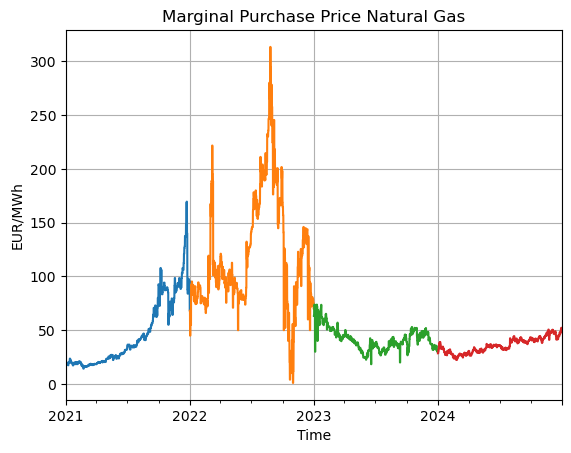

In [37]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2023"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.xlim("2021-01-01", "2024-12-31")
plt.title("Marginal Purchase Price Natural Gas")
plt.grid()

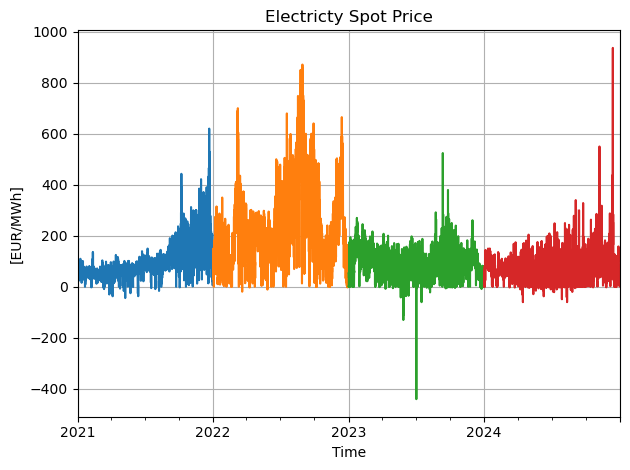

In [38]:
elspotprices["SpotPriceEUR"]["2021"].plot()
elspotprices["SpotPriceEUR"]["2022"].plot()
elspotprices["SpotPriceEUR"]["2023"].plot()
elspotprices["SpotPriceEUR"]["2024"].plot()
plt.ylabel("[EUR/MWh]")
plt.xlabel("Time")
plt.grid()
plt.title("Electricty Spot Price")
#plt.legend(["2021", "2022", "2023", "2024"])
plt.tight_layout()
plt.show()

Text(0, 0.5, 't_Co2/MWh')

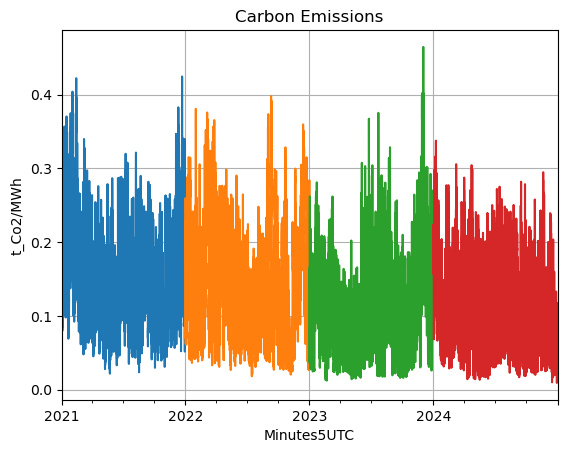

In [45]:
grid_emissions["2021"].plot()
grid_emissions["2022"].plot()
grid_emissions["2023"].plot()
grid_emissions["2024"].plot()
plt.title("Carbon Emissions")
plt.grid()
plt.ylabel("t_Co2/MWh")

In [57]:
def add_carriers(n):
    
    n.add("Carrier", "onshorewind")
    n.add("Carrier", "solar")

    n.add("Carrier", "imports")
    n.add("Carrier", "exports")

    n.add("Carrier", "battery_storage")
    #n.add("Carrier", "battery charging")
    #n.add("Carrier", "battery dicharging")

    n.add("Carrier","gas") 
    n.add("Carrier", "NG_boiler")

    n.add("Carrier", "pellets")

    n.add("Carrier","Pyrolysis")
    n.add("Carrier", "Biogas_plant")

    n.add("Carrier", "El_Boiler")
    
    n.add("Carrier", "RONDO_store")
    n.add("Carrier", "RONDO_charge")
    n.add("Carrier", "RONDO_discharge")

    n.add("Carrier", "biochar")
    n.add("Carrier", "biomass", unit = "t/h")
    n.add("Carrier", "CO2", unit = "t/h") 

    n.add("Carrier", "methanol")
    n.add("Carrier", "Methanolisation")

    n.add("Carrier", "methane")

    n.add("Carrier", "heat")
    n.add("Carrier", "electricity")

In [47]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        #marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        #marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

In [59]:
def add_grid(n, price_import, price_export, grid_emissions, CO2tax):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=False,
          p_nom = 84, # GCP limit
          efficiency=1.0,
          marginal_cost=0,
          capital_cost=0.0,
          carrier="imports")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="imports",
          marginal_cost=price_import + grid_emissions*CO2tax)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          #e_nom = 130e3, # MWh 
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="exports")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="exports",
          marginal_cost=price_export)

In [54]:
def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery_storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [52]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        #e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = e_nom_store,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        carrier = "RONDO_store",
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        p_nom_max = p_nom_charge, 
        # p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "RONDO_charge",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_MT",
        #p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        p_nom_max = p_nom_discharge,
        efficiency=0.90*0.8, # Including Efficency of Heat Exchanger here
        carrier = "RONDO_discharge",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [92]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom_min = 10,
        p_nom_max = 10,
        efficiency=0.9,
        carrier = "El_Boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        #marginal_cost = costs.at["electric boiler steam","marginal_cost"]
        )

In [55]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        marginal_cost = NG_price + 0.202*CO2tax + 1.007, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        carrier = "NG_boiler",
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,) 

In [ ]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store",
    "pellets store",
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = True)
    
    # straw pellets cost from 35 - 82 EUR/ton
    # LHV_pellets = 16 MJ/kg
    

    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="biochar",
        bus3 = "Greenlab",
        p_nom_extendable=False,
        p_nom=2,
        efficiency = 8.5/20, # MW , 8.2/21.7 , Heat High Temp
        efficiency2 = 9/20, # MW , 10.1/21.7 , Biochar
        efficiency3 = -0.02, # MW, auxillary power (2 %)
        carrier="pyrolysis",
        capital_cost=costs.at["biochar pyrolysis","capital_cost"],
        marginal_cost = 0) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom = 1, # MW  
        p_nom_extendable = False,
        marginal_cost= -0.313*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom = 8e3,
        e_nom_extendable=False,
        e_cyclic=False,
        carrier="biochar")

In [56]:
def heat_load(n,P_heat = 5):
    n.add("Load", "Biogas_Heat", carrier = "heat",
        bus = "Heat_MT",
        p_set = P_heat)

def el_load(n,P_el = 2):
    n.add("Load", "Biogas_el", carrier = "electrcity",
        bus = "Greenlab",
        p_set = P_el)

In [89]:
def build_network_simple(P_heat,P_el ,CO2_tax, grid_emissions,p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    
    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values
    grid_emissions = grid_emissions.loc[n.snapshots].values

    
    add_carriers(n)



    n.add("Bus", "Greenlab", carrier = "electricity")
    add_skive_generators(n,s_cf,w_cf)

    n.add("Bus", "Grid_Import", carrier  = "imports")
    n.add("Bus", "Grid_Export", carrier = "exports")
    add_grid(n, price_import = p_import, price_export = p_export, grid_emissions = grid_emissions, CO2tax = CO2_tax)


    n.add("Bus", "Heat_MT", carrier = "heat")
    add_electric_boiler(n)


    n.add("Bus", "NG", carrier = "gas")
    add_NG_boiler(n,CO2tax = CO2_tax, NG_price = NG_price)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals = True,
            solver_name="gurobi", 
            horizon=horizon, overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [90]:
build_network_simple(P_heat = 5,P_el = 2 ,CO2_tax = 80, grid_emissions = grid_emissions["2021"],p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

Index(['Boiler_Skive'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 17.68it/s]
INFO:linopy.io: Writing time: 2.06s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

Solved in 19 iterations and 0.39 seconds (0.25 work units)


INFO:gurobipy:Solved in 19 iterations and 0.39 seconds (0.25 work units)


Optimal objective -1.072734794e+07


INFO:gurobipy:Optimal objective -1.072734794e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87542 primals, 210099 duals
Objective: -1.07e+07
Solver model: available
Solver message: 2



PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 5
 - Carrier: 22
 - Generator: 4
 - Link: 4
 - Store: 1
Snapshots: 8754